In [1]:
!pip install opencv-python matplotlib

In [4]:
from google.colab import files

uploaded = files.upload ()

Saving image for lab10 right.png to image for lab10 right.png
Saving image for lab10 left.png to image for lab10 left.png


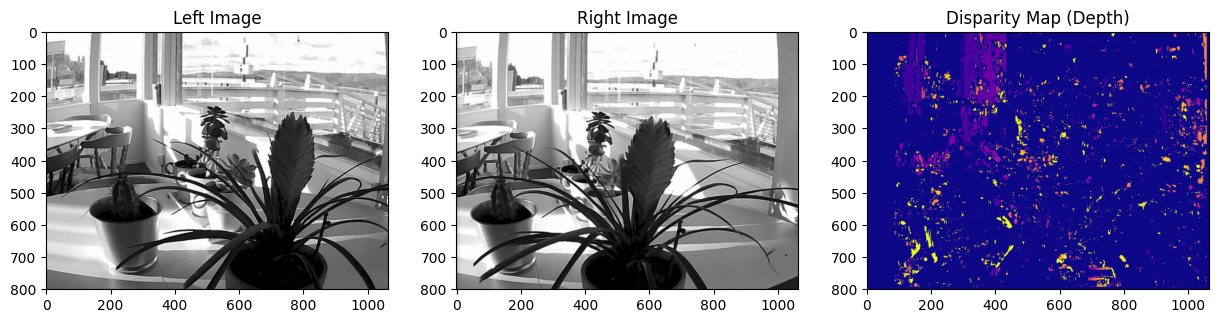

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


left_img  = cv2.imread('/content/image for lab10 left.png', 0)
right_img = cv2.imread('/content/image for lab10 right.png', 0)

# Get dimensions of both images
h_left, w_left = left_img.shape
h_right, w_right = right_img.shape

# Resize images to a common size (e.g., the minimum height and width)
common_h = min(h_left, h_right)
common_w = min(w_left, w_right)

left_img = cv2.resize(left_img, (common_w, common_h))
right_img = cv2.resize(right_img, (common_w, common_h))

stereo = cv2.StereoBM_create(numDisparities=16*5, blockSize=15)


disparity = stereo.compute(left_img, right_img)


disparity_norm = cv2.normalize(disparity, None, alpha=0, beta=255,
                                norm_type=cv2.NORM_MINMAX)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Left Image")
plt.imshow(left_img, cmap='gray')

plt.subplot(1,3,2)
plt.title("Right Image")
plt.imshow(right_img, cmap='gray')

plt.subplot(1,3,3)
plt.title("Disparity Map (Depth)")
plt.imshow(disparity_norm, cmap='plasma')

plt.show()